In [1]:
import os
# Inspect Kaggle input directory
for root, dirs, files in os.walk(
    "/kaggle/input/banalyzer-banana-ripeness-classification-dataset/banana_data/data"
):
    if len(files) > 0:
        print(f"Directory: {root} | File count: {len(files)}")

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# 1. Dataset Configuration
BASE_DIR = "/kaggle/input/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset/banana_data/data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [6]:
# Automatically split into 80% train / 20% validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
print("Classes detected in train:", class_names)

# Pipeline optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1000 files belonging to 4 classes.
Using 800 files for training.


I0000 00:00:1789119193.002567      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789119193.008515      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1000 files belonging to 4 classes.
Using 200 files for validation.
Found 200 files belonging to 4 classes.
Classes detected in train: ['overripe', 'ripe', 'rotten', 'unripe']


In [7]:
# Augmentation pipeline
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1),
    ]
)

# Base model with pre-trained ImageNet weights
base_model = MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False

# Architecture
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train
history = model.fit(train_ds, validation_data=val_ds, epochs=8)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step - accuracy: 0.4913 - loss: 1.2569 - val_accuracy: 0.7350 - val_loss: 0.6760
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7550 - loss: 0.6258 - val_accuracy: 0.8400 - val_loss: 0.4712
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8213 - loss: 0.4566 - val_accuracy: 0.8650 - val_loss: 0.4021
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8438 - loss: 0.3882 - val_accuracy: 0.8850 - val_loss: 0.3621
Epoch 5/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8700 - loss: 0.3301 - val_accuracy: 0.8900 - val_loss: 0.3349
Epoch 6/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8725 - loss: 0.3327 - val_accuracy: 0.9200 - val_loss: 0.3207
Epoch 7/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8900 - loss: 0.3064 - val_accuracy: 0.9000 - val_loss: 0.3169
Epoch 8/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.902

In [8]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - accuracy: 0.8500 - loss: 0.4067
Final Test Accuracy: 85.00%
Final Test Loss: 0.4067


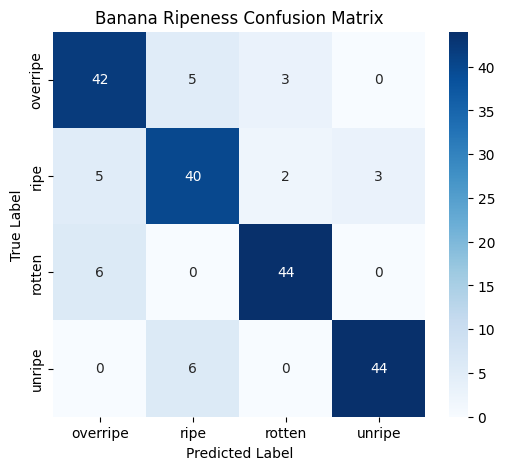

              precision    recall  f1-score   support

    overripe       0.79      0.84      0.82        50
        ripe       0.78      0.80      0.79        50
      rotten       0.90      0.88      0.89        50
      unripe       0.94      0.88      0.91        50

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect true and predicted labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Banana Ripeness Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [10]:
# Save the model to Kaggle's working directory
model.save("/kaggle/working/banana_ripeness_detector.keras")
print(
    "Model saved successfully to /kaggle/working/banana_ripeness_detector.keras"
)

Model saved successfully to /kaggle/working/banana_ripeness_detector.keras
